In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import division

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter
#matplotlib.rcParams['savefig.dpi'] = 1.5 * matplotlib.rcParams['savefig.dpi']

import os, glob, time, sys, functools
import corner
import numpy as np

import scipy
import scipy.constants as sc
import scipy.integrate as si
import scipy.signal as ssig
import scipy.interpolate as scint
import scipy.linalg as sl

# from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
# import acor

In [3]:
import astropy.constants as const
import astropy.units as u

In [4]:
# import libstempo as T2
# from libstempo import toasim as LT
# from libstempo import plot as LP
# from libstempo import eccUtils as eu

# import enterprise
# from enterprise.pulsar import Pulsar
# from enterprise.signals import parameter
# from enterprise.signals import selections
# from enterprise.signals import signal_base
# import enterprise.signals.signal_base as base
# from enterprise.signals import white_signals
# from enterprise.signals import gp_signals
# from enterprise.signals import deterministic_signals
# from enterprise.signals import utils
# from enterprise import constants as const

# import enterprise_extensions as ee
# from enterprise_extensions import models, model_utils, blocks

In [5]:
import PhenomA as pa
import observatories as obs
import WaveformTools as wt
import WaveformTools_old as wto
import utils

In [6]:
# Msol = const.GMsun / const.c**3

In [7]:
# def omega_isco(Mtot):
#     Mtot = utils.assert_units(Mtot,u.Msun)
#     return 6**(-3/2) / (Mtot*const.G/const.c**3).decompose()

In [8]:
wt.get_omega_isco(1e9)

<Quantity 1.38141319e-05 1 / s>

In [9]:
def omega_pterm(Mtot, q, pd):
    '''
    Arguments
    ------------------
    Mtot (float or astropy.Quantity):
        Total binary mass in solar masses.
    q (float):
        Mass ratio
    pd (float or astropy.Quantity):
        Pulsar distance in kpc.

    Returns
    -------------------
    fgw_isco (astropy.Quantity)
        GW frequency at the ISCO, in Hz.
    fgw_pulsar (astropy.Quantity)
        GW frequency in the pulsar term, in Hz.
    '''
    Mtot = utils.assert_units(Mtot,u.Msun)
    pd = utils.assert_units(pd,u.kpc)
    
    mc = (q**(3.0/5.0) / (1.0 + q)**(6.0/5.0)) * Mtot
    
    # convert units
    mc = (mc.value*wt.TSUN)*u.s        # convert from solar masses to seconds (geometric units)
    
    # define initial orbital frequency 
    w0 = wt.get_omega_isco(Mtot)
    w053 = w0**(-5/3)

    # various factors invloving GW parameters
    fac1 = (256/5 * mc**(5/3) * w0**(8/3) ).decompose()

    #cosMu = -np.dot(omhat, phat)

    # convert units
    pd_new = (pd/const.c).to(u.s) # convert from kpc to seconds of light travel time

    # get pulsar time
    tp = 0 - pd_new * 2 #(1-cosMu)

    # calculate frequency at pulsar
    omega_p = w0 * (1 - (fac1 * tp).decompose())**(-3/8)

    ## returns orbital angular frequency / pi, ergo twice the orbital frequency, ergo the GW frequency at ~merger and in pulsar
    return (w0.to(u.Hz)/np.pi, omega_p.to(u.Hz)/np.pi)

In [10]:
omega_pterm(1e8,1.0,1.0)

(<Quantity 4.39717476e-05 Hz>, <Quantity 1.45304941e-07 Hz>)

In [11]:
Mtot_sample = 10**np.random.uniform(6,11,size=int(1e4))
pd_sample = 10**np.random.uniform(-1,2,size=int(1e4))

In [12]:
all_binaries = omega_pterm(Mtot_sample,1.0,pd_sample)

In [13]:
idx = np.logical_and(all_binaries[1]<5e-7*u.Hz, all_binaries[0]>1e-6*u.Hz)

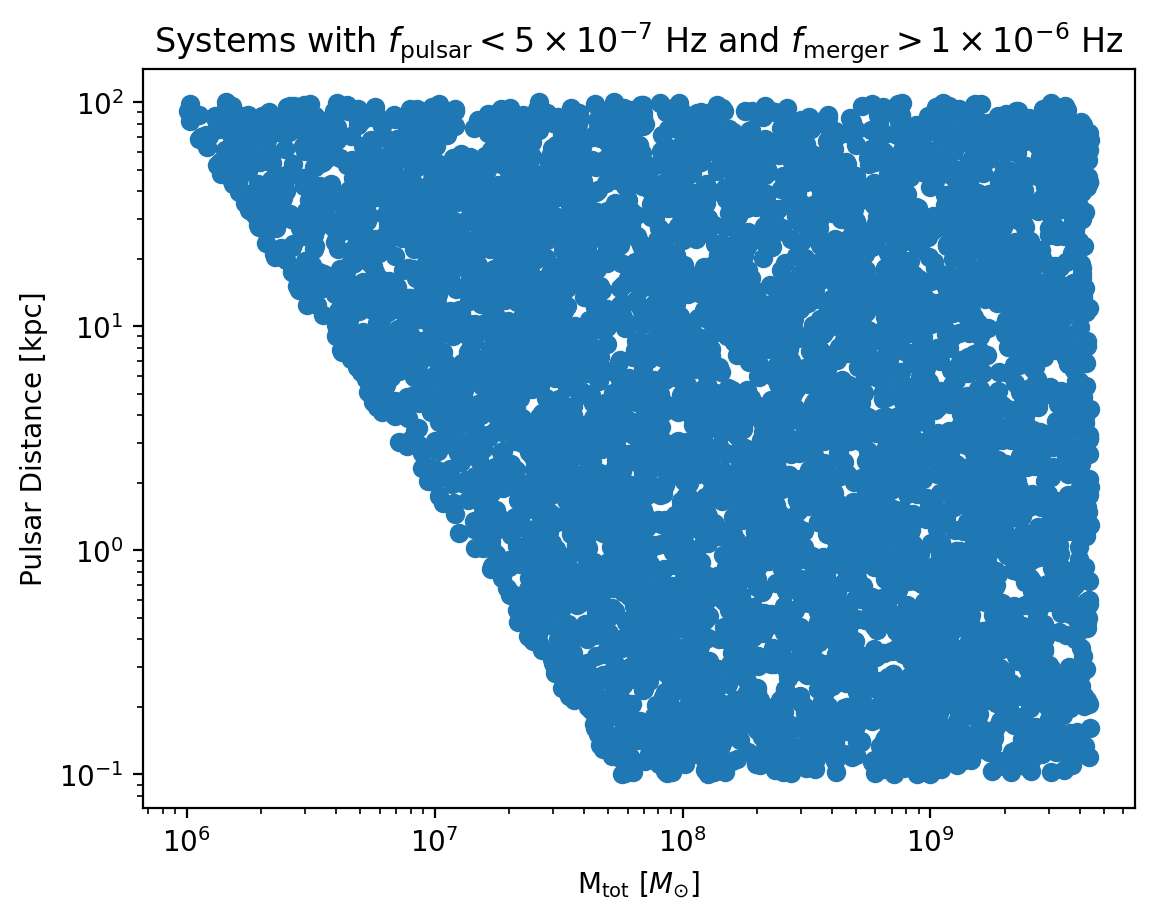

In [14]:
plt.scatter(Mtot_sample[idx],pd_sample[idx]);
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\mathrm{M_{tot}}$ $[M_{\odot}]$")
plt.ylabel(r"Pulsar Distance [kpc]")
plt.title(r"Systems with $f_{\rm pulsar}<5\times10^{-7}$ Hz and $f_{\rm merger}>1\times10^{-6}$ Hz")
plt.show()

In [15]:
a = None
b = 2
(a is None) ^ (b is None), True ^ True

(True, False)

In [17]:
# create LISA object
lisa = obs.LISA() 

## temp
# lisa.name = 'LISA'

m1 = Mtot_sample[idx].copy() * 0.5
m2 = Mtot_sample[idx].copy() * 0.5
z = 0.5 * np.ones(len(Mtot_sample[idx]))
T_merge = 1.*obs.YEAR

snr = []
for ii in range(len(Mtot_sample[idx])):
    binary = wt.Binary(m1[ii], m2[ii] , z=z[ii]);


    snr.append(binary.run_full_SNR_calc(lisa,T_merge))
    # binary.T_merge = T_merge*u.s
    # binary.SetFreqBounds(lisa);

    # freqs, X_char = binary.CalcStrain(lisa);
    # snr.append(binary.CalcSNR(freqs, X_char, lisa));
    #print(snr[ii])

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

...

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
Redshift provided. 
	Luminosity Distance.....

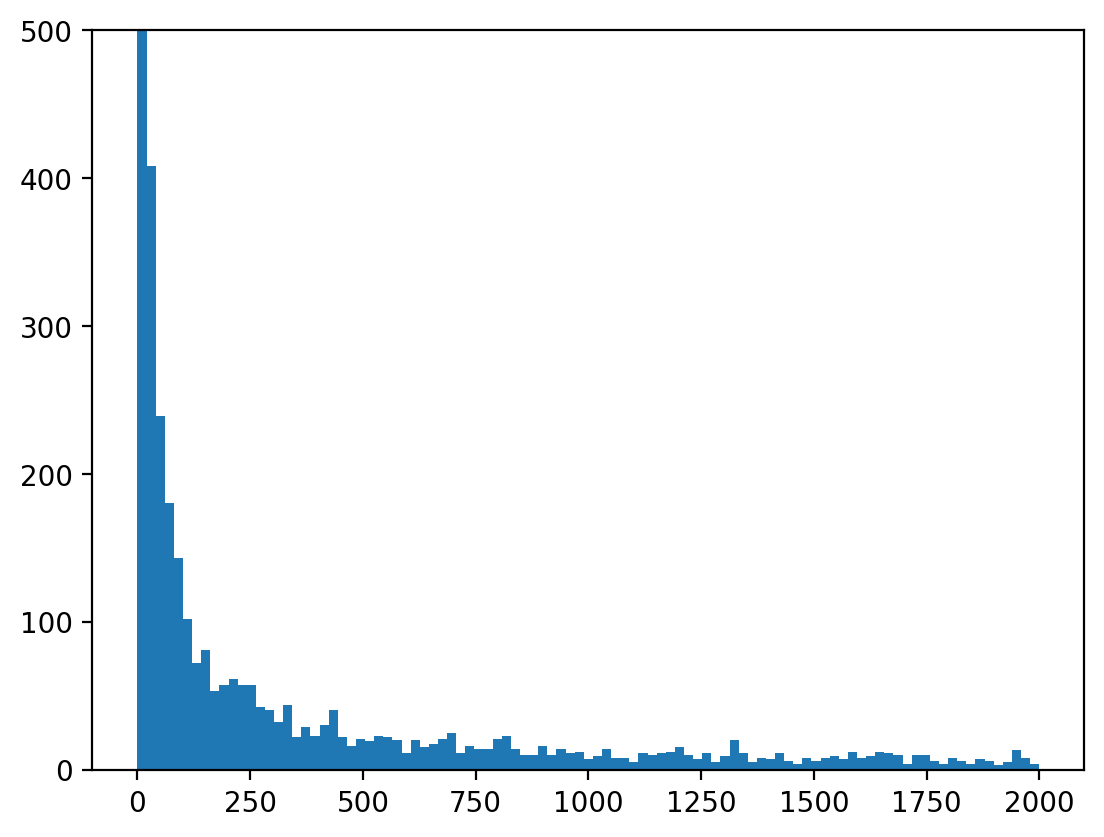

In [18]:
plt.figure()
plt.hist(snr,bins=np.linspace(0,2000,100))
plt.ylim(0,500)
plt.show()

In [19]:
lisa_snr_min = 50
mask = np.array(snr) > lisa_snr_min

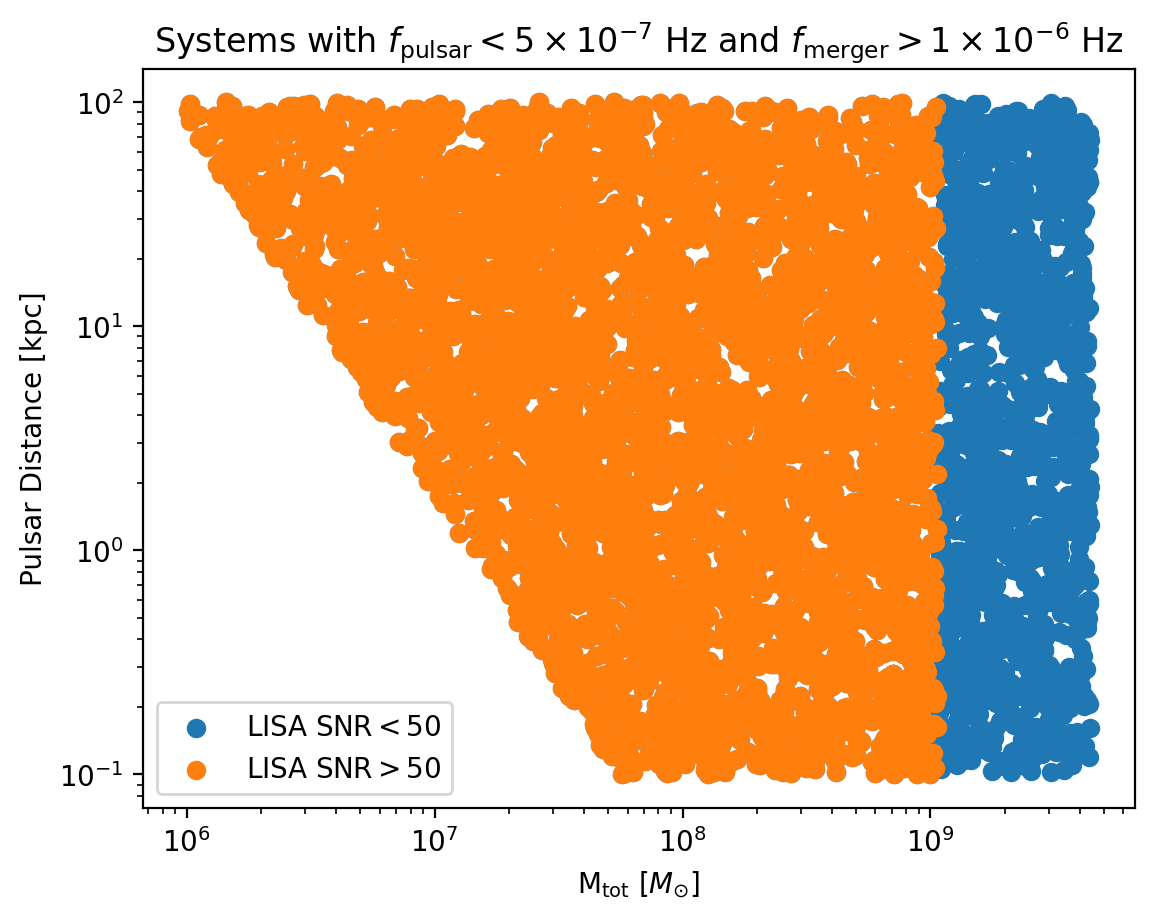

In [20]:
plt.scatter(Mtot_sample[idx],pd_sample[idx],label=r'LISA SNR$<{}$'.format(lisa_snr_min))
plt.scatter(Mtot_sample[idx][mask],pd_sample[idx][mask],label=r'LISA SNR$>{}$'.format(lisa_snr_min))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\mathrm{M_{tot}}$ $[M_{\odot}]$")
plt.ylabel(r"Pulsar Distance [kpc]")
plt.title(r"Systems with $f_{\rm pulsar}<5\times10^{-7}$ Hz and $f_{\rm merger}>1\times10^{-6}$ Hz")
plt.legend()
plt.show()

In [21]:
ii = np.argmin(np.abs(np.array(snr) - 500))
binary = wt.Binary(m1[ii] , m2[ii], z=z[ii])
binary.run_full_SNR_calc(lisa,T_merge)

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


499.8377729485642

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc
499.8377729485642


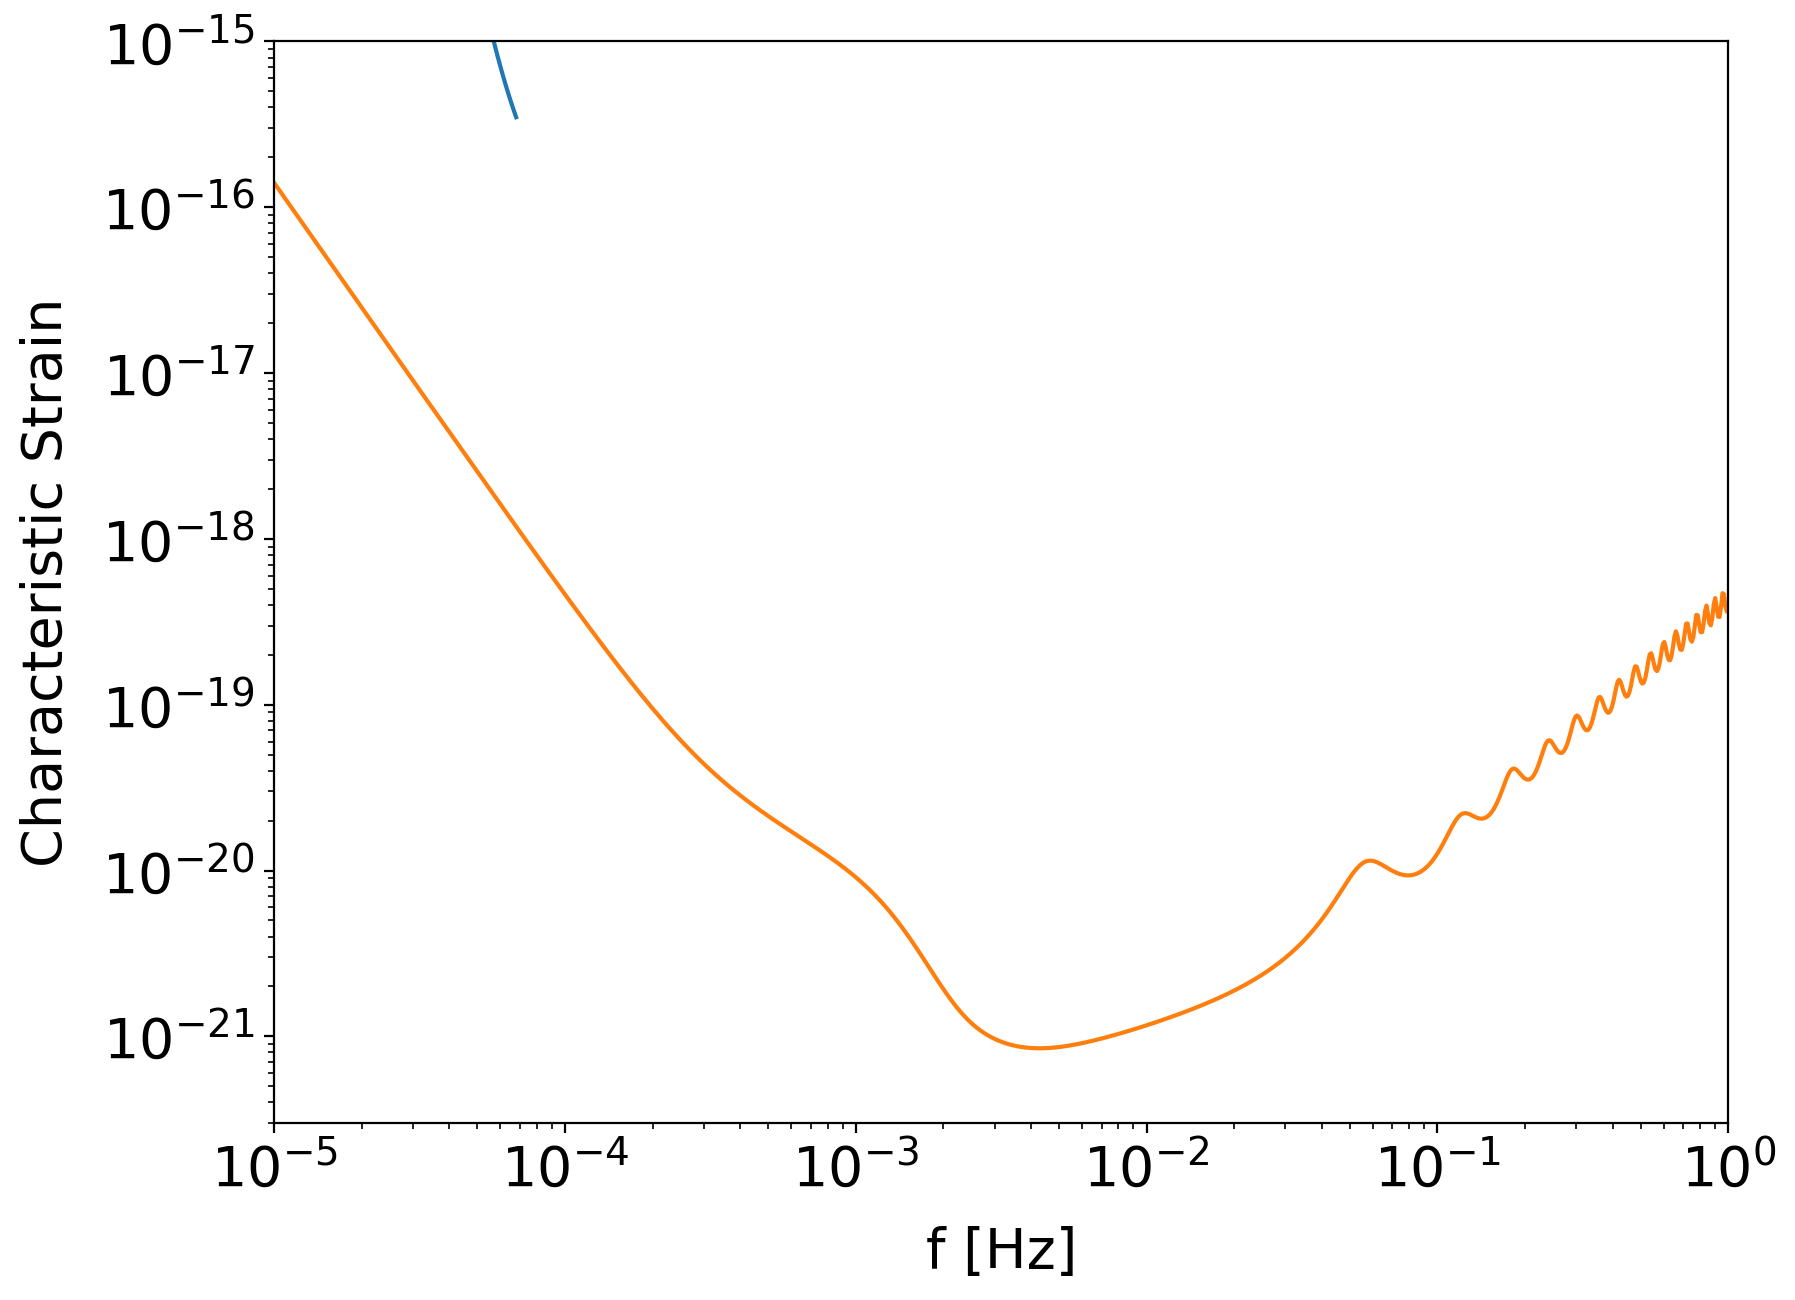

In [22]:
binary = wt.Binary(m1[ii] , m2[ii], z=z[ii])

binary.T_merge = T_merge*u.s
binary.SetFreqBounds(lisa)

freqs, X_char = binary.CalcStrain(lisa)
print(binary.CalcSNR(freqs, X_char, lisa))
binary.PlotStrain(freqs, X_char, lisa)

Redshift provided. 
	Luminosity Distance........... 2864.3375084941295 Mpc
499.83734068685726


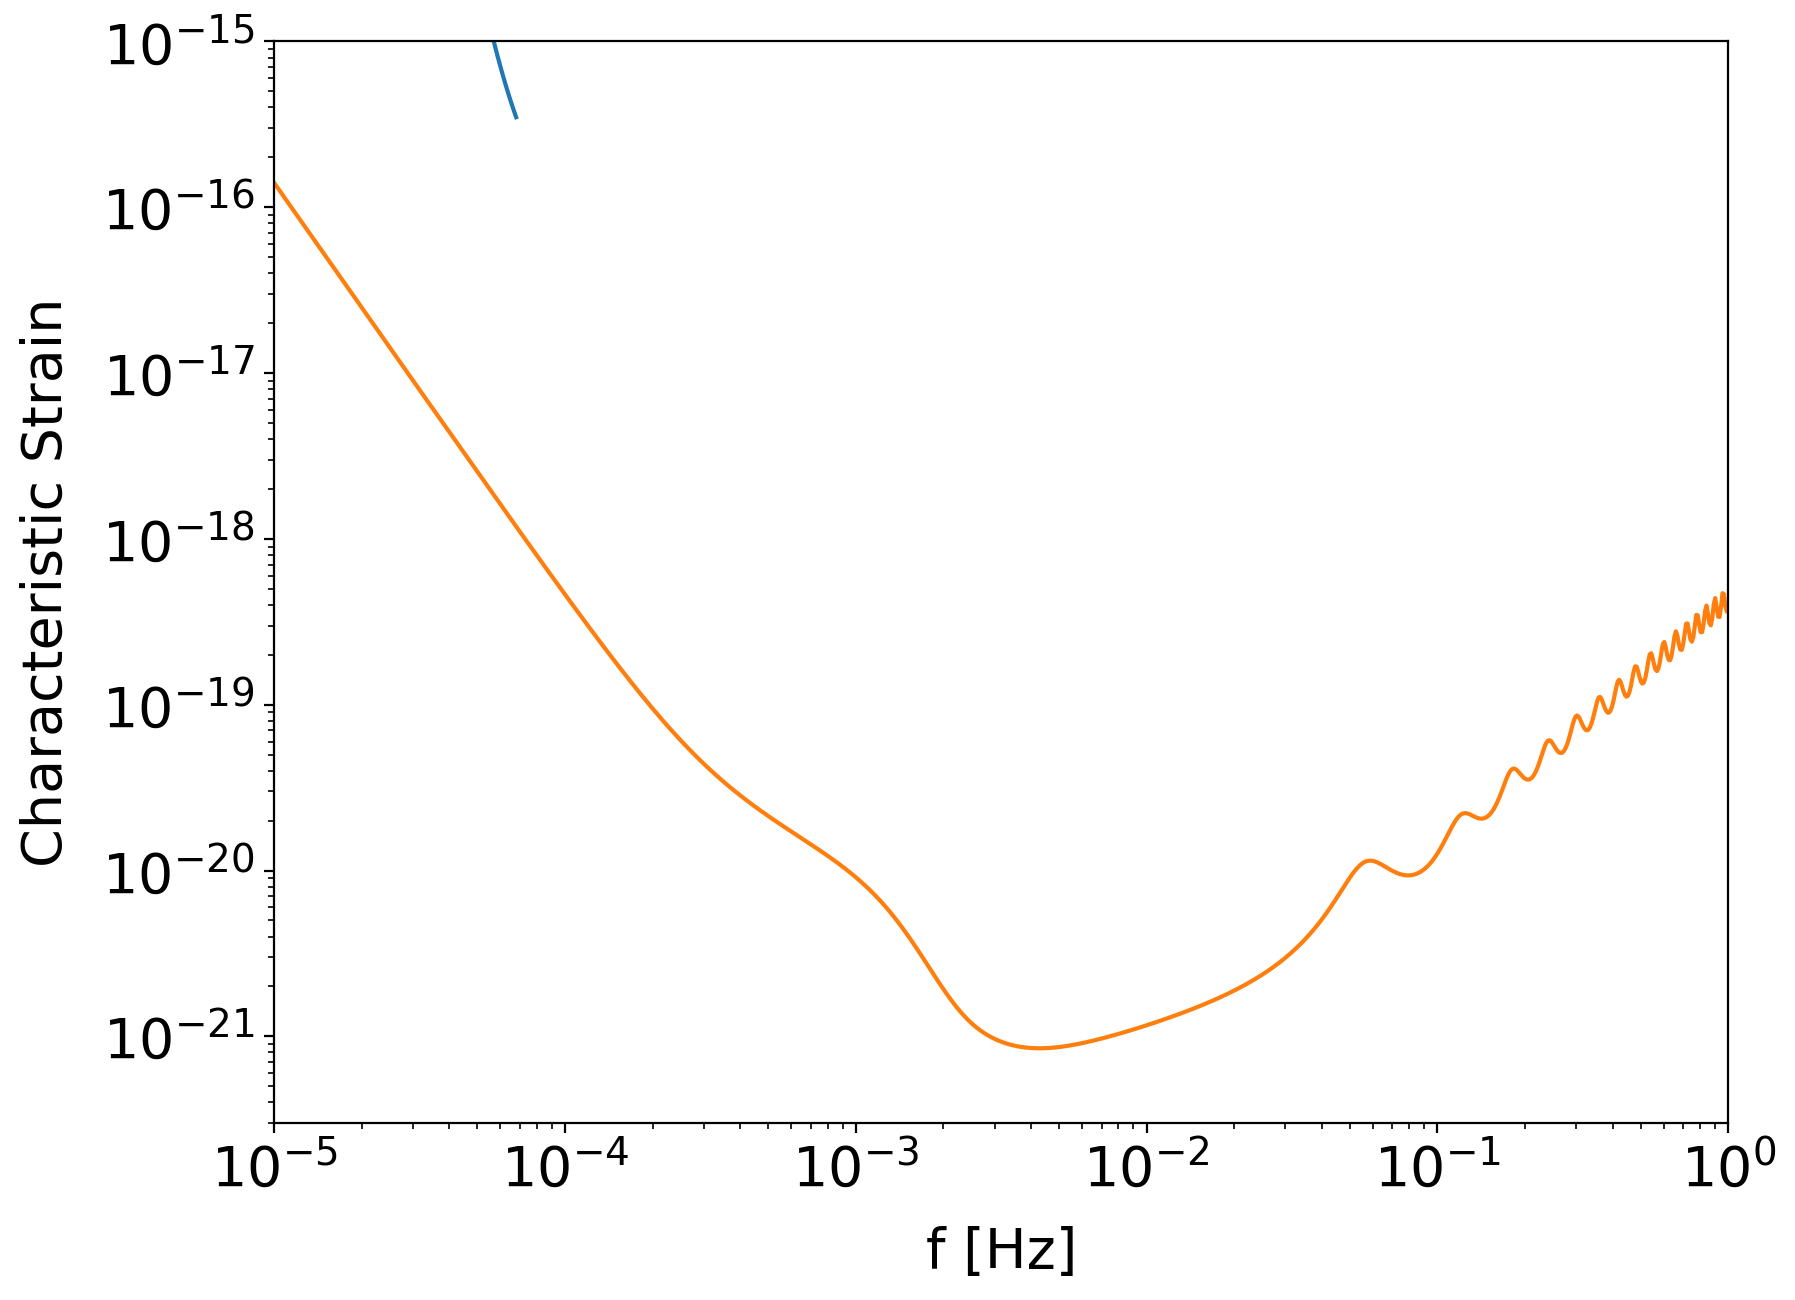

In [23]:

binary_old = wto.Binary(m1[ii]*pa.TSUN , m2[ii]*pa.TSUN, z=z[ii])

binary_old.T_merge = T_merge
binary_old.SetFreqBounds(lisa)

freqs_old, X_char_old = binary_old.CalcStrain(lisa)
print(binary_old.CalcSNR(freqs_old, X_char_old, lisa))
binary_old.PlotStrain(freqs_old, X_char_old, lisa)

In [24]:
binary.f_start, binary_old.f_start

(<Quantity 1.81958354e-06 Hz>, 1.8195835432518956e-06)

In [25]:
binary.f_end, binary_old.f_end

(<Quantity 6.79342181e-05 Hz>, 6.793421809947264e-05)

In [26]:
binary.geom_eta, binary_old.eta

(0.25, 0.25)

In [27]:
(freqs/freqs_old)[-1]

1.0

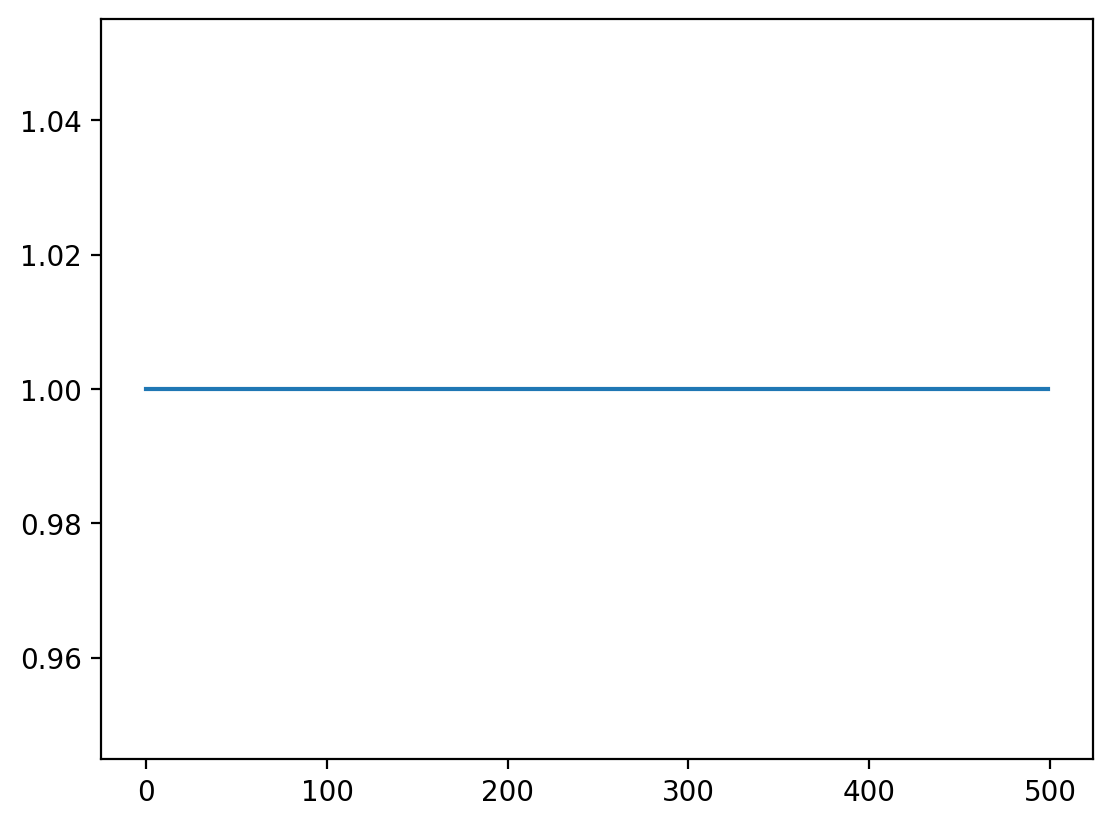

In [28]:
plt.figure()
plt.plot(X_char/X_char_old)


Okay NOW everything is actually consistent. Good.

In [42]:
a = np.random.rand(2,5)

In [43]:
a

array([[0.62187607, 0.0662858 , 0.13819254, 0.70337704, 0.55928694],
       [0.68244309, 0.51793736, 0.50981039, 0.65555697, 0.77881666]])

In [45]:
a.T

array([[0.62187607, 0.68244309],
       [0.0662858 , 0.51793736],
       [0.13819254, 0.50981039],
       [0.70337704, 0.65555697],
       [0.55928694, 0.77881666]])


## eccentricity

In [196]:
# solve coupled system of equations to get pulsar term values

tp = 0 - eu.KPC2S * 2
y = utils.solve_coupled_ecc_solution(omega_isco(1e8)/np.pi/2, 0.0001, 0.0, 0.0, 1e8,
                                     1.0, np.array([0.0, tp]))

In [197]:
y

array([[ 2.19858738e-05,  1.00000000e-04,  0.00000000e+00,
         0.00000000e+00],
       [ 4.28948421e-08,  7.18109094e-02, -2.18432938e+03,
        -8.91186642e+04]])